# 迁移学习与微调

> **斯坦福 CS231n** | Transfer Learning and Fine-tuning

## 本章导读

迁移学习将在大规模数据集上预训练的模型迁移到小数据集上，是深度学习最实用的技术之一。本节从直觉到代码，完整理解特征提取和微调策略。

**学习目标：**
- 理解预训练模型的概念和价值
- 区分特征提取（冻结）与微调（解冻）
- 实现渐进式解冻策略
- 比较 random init vs pretrained 的效果
- 理解不同层的学习率设置

**参考来源：** [CS231n Transfer Learning](https://cs231n.github.io/transfer-learning/) | [torchvision models](https://pytorch.org/vision/stable/models.html)

## 1. 直觉理解：迁移学习为什么有效？

### 核心问题

在 ImageNet（1400 万图像）上训练一个 ResNet 需要数周和大量算力。但如果你只有 1000 张猫狗图片，如何获得高质量模型？

### 迁移学习的思想

**预训练 + 微调**：
1. 在大数据集上预训练（如 ImageNet）
2. 在目标数据集上微调或提取特征

### 为什么有效？

CNN 的层级特征具有迁移性：
- **浅层**（边缘、纹理）：通用特征，跨领域可迁移
- **深层**（物体部件、语义）：领域相关，需微调

[[Yosinski et al., 2014]](https://arxiv.org/abs/1411.1792) 实验证明：特征可迁移性随层深度递减。

### 三种迁移学习策略

| 策略 | 预训练层 | 新层 | 训练方式 | 适用场景 |
|------|----------|------|----------|----------|
| **特征提取** | 全部冻结 | 仅分类头 | 只训练新层 | 小数据集（<1K） |
| **微调** | 全部解冻 | 分类头 | 全部训练 | 中等数据集（1K-100K） |
| **渐进式解冻** | 逐层解冻 | 分类头 | 从深到浅逐步 | 平衡稳定性和性能 |

## 2. 手算验证：特征提取 vs 随机初始化

### 特征提取的数学表示

预训练模型 $f_{pre}$ 的编码器部分 $g(\cdot)$ 固定不动，只训练线性分类器 $W$：

$$\text{features} = g(x; \theta_{pre}) \quad \text{(frozen)}$$
$$\hat{y} = W \cdot \text{features} + b \quad \text{(trainable)}$$

### 效果对比

假设 3 类分类任务，100 个样本：
- **随机初始化**：$W$ 从随机开始，需要学习所有特征——需要大量数据
- **特征提取**：$g$ 已提取良好特征，$W$ 只需学习简单线性映射——需要很少数据

### 手算：线性可分性

预训练特征可能已经线性可分。设 2D 特征 3 类：
- 类 0 中心：$(0, 0)$
- 类 1 中心：$(3, 3)$
- 类 2 中心：$(-3, 3)$

简单最近邻或线性分类器即可达到接近 100% 准确率——因为预训练特征已经很好地分离了类别。

Visualization 1: Pretrained vs random features


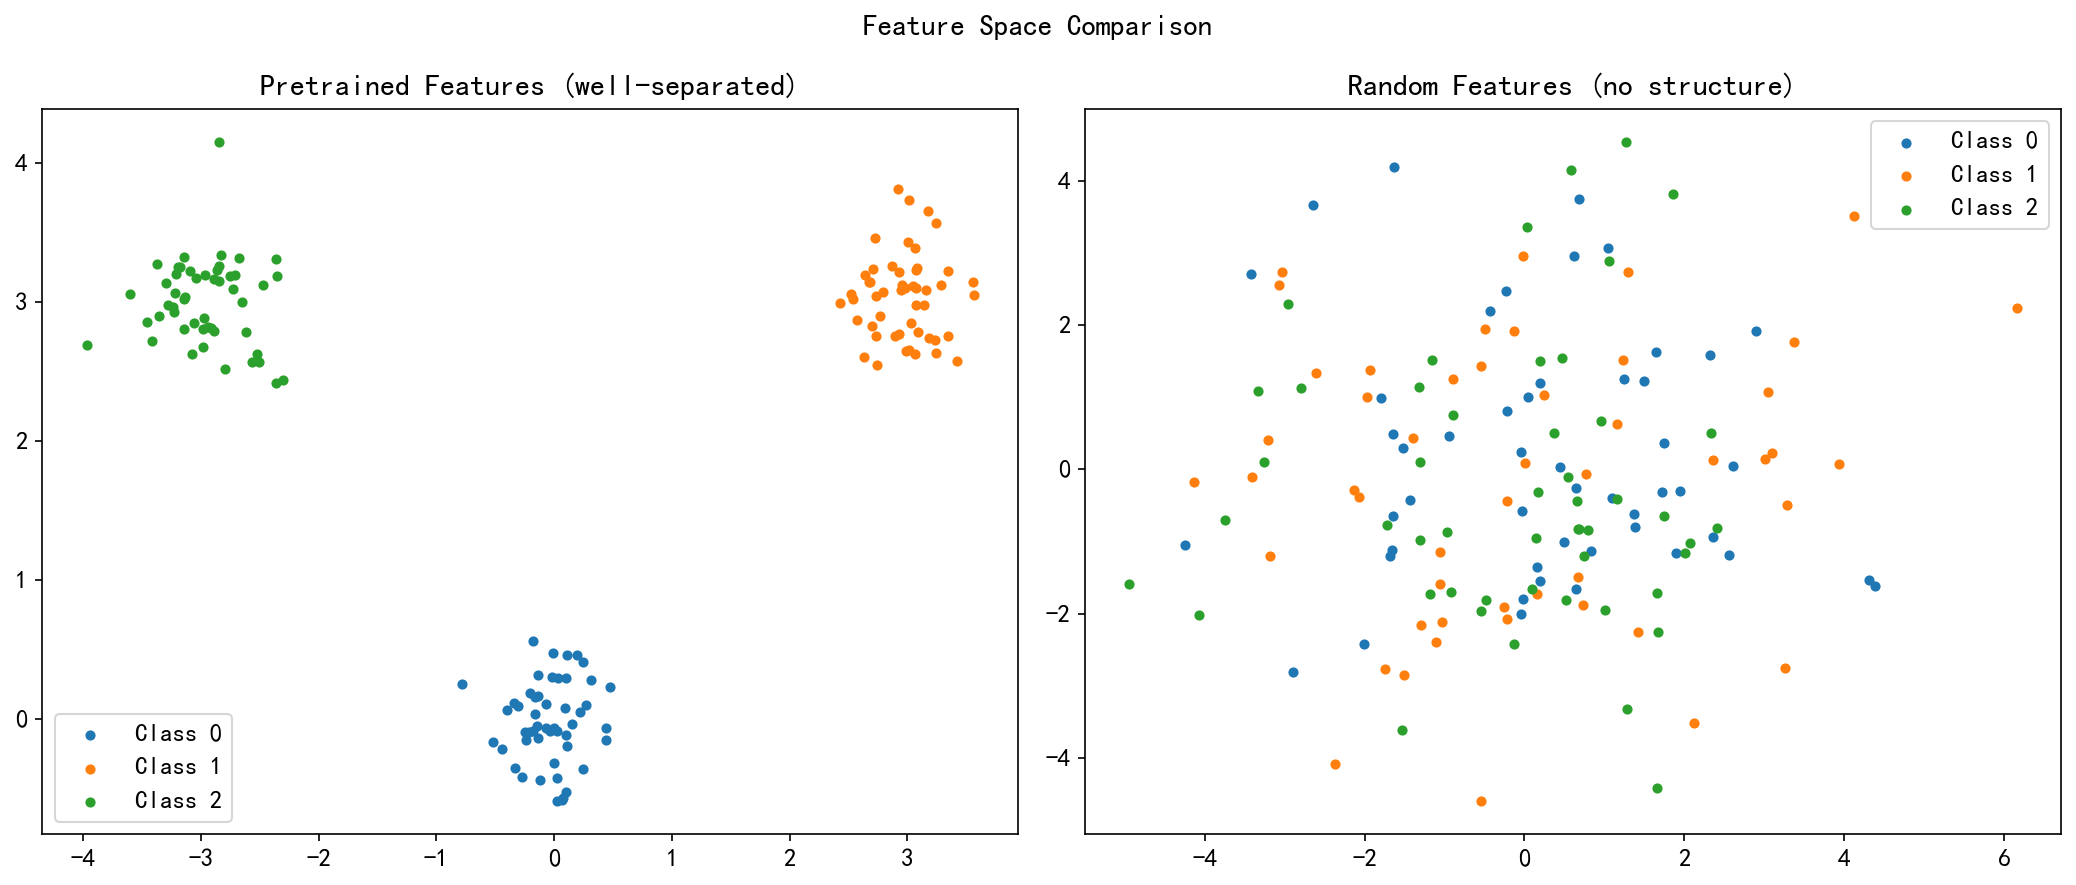

In [5]:
# Verify: feature extraction vs random init
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# Simulate pretrained features (well-separated clusters)
n_per_class = 50
centers = np.array([[0, 0], [3, 3], [-3, 3]])
pretrained_features = []
labels = []
for c in range(3):
    feat = centers[c] + np.random.randn(n_per_class, 2) * 0.3
    pretrained_features.append(feat)
    labels.extend([c] * n_per_class)
X_pre = np.vstack(pretrained_features)
y_pre = np.array(labels)

# Simulate random features (no structure)
X_random = np.random.randn(150, 2) * 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for c in range(3):
    mask = y_pre == c
    axes[0].scatter(X_pre[mask, 0], X_pre[mask, 1], label=f'Class {c}', s=15)
axes[0].set_title('Pretrained Features (well-separated)')
axes[0].legend()
for c in range(3):
    mask = y_pre == c
    axes[1].scatter(X_random[mask, 0], X_random[mask, 1], label=f'Class {c}', s=15)
axes[1].set_title('Random Features (no structure)')
axes[1].legend()
plt.suptitle('Feature Space Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('feature_space_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Pretrained vs random features")

## 3. 代码实现：迁移学习模拟

用 numpy 模拟预训练模型：先在大数据集上"预训练"，再在小数据集上"迁移"。

In [7]:
class PretrainedModel:
    """Simulate a pretrained model with feature extractor + classifier."""
    def __init__(self, input_dim, hidden_dims, n_classes):
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims)-1):
            W = np.random.randn(dims[i+1], dims[i]) * np.sqrt(2.0 / dims[i])
            b = np.zeros(dims[i+1])
            layers.append({'W': W, 'b': b})
        # Classifier head
        W_out = np.random.randn(n_classes, dims[-1]) * np.sqrt(2.0 / dims[-1])
        b_out = np.zeros(n_classes)
        layers.append({'W': W_out, 'b': b_out})
        self.layers = layers
        self.n_layers = len(layers)
    
    def forward(self, X):
        """Forward pass, return activations for each layer."""
        activations = [X]
        cache = []
        a = X
        for i, layer in enumerate(self.layers):
            z = a @ layer['W'].T + layer['b']
            if i < self.n_layers - 1:
                a = np.maximum(0, z)  # ReLU for hidden layers
            else:
                a = z  # No activation for output
            activations.append(a)
            cache.append((layer, z, a))
        return a, activations, cache
    
    def extract_features(self, X, layer_idx=None):
        """Extract features from a specific layer."""
        if layer_idx is None:
            layer_idx = self.n_layers - 2  # last hidden layer
        _, activations, _ = self.forward(X)
        return activations[layer_idx + 1]
    
    def train_step(self, X, y, lr=0.01, freeze_layers=0):
        """Train one step. freeze_layers=number of layers to freeze (from start)."""
        scores, activations, cache = self.forward(X)
        N = X.shape[0]
        
        # Softmax loss
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_s = np.exp(shifted)
        probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
        loss = -np.log(probs[np.arange(N), y]).mean()
        
        # Backward
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        
        da = dscores
        for i in range(self.n_layers - 1, -1, -1):
            if i < freeze_layers:
                break  # frozen layer
            layer, z, a = cache[i]
            dW = da.T @ activations[i]
            db = da.sum(axis=0)
            if i > 0:
                da = (da @ layer['W']) * (activations[i] > 0)
            layer['W'] -= lr * dW
            layer['b'] -= lr * db
        
        return loss
    
    def predict(self, X):
        scores, _, _ = self.forward(X)
        return np.argmax(scores, axis=1)

print("PretrainedModel class defined")

PretrainedModel class defined


In [8]:
# Phase 1: Pretrain on large dataset (many classes)
np.random.seed(42)
n_pretrain_classes = 10
input_dim = 20
pretrain_model = PretrainedModel(input_dim, [32, 16], n_pretrain_classes)

# Generate large pretraining dataset
n_pretrain = 500
X_pretrain = np.random.randn(n_pretrain, input_dim)
# Add class structure
y_pretrain = np.random.randint(0, n_pretrain_classes, n_pretrain)
# Inject class-dependent patterns
for c in range(n_pretrain_classes):
    mask = y_pretrain == c
    X_pretrain[mask] += np.random.randn(mask.sum(), input_dim) * 0.5 + c

print("Phase 1: Pretraining...")
pretrain_losses = []
for epoch in range(300):
    loss = pretrain_model.train_step(X_pretrain, y_pretrain, lr=0.05)
    pretrain_losses.append(loss)
    if epoch % 100 == 0:
        acc = np.mean(pretrain_model.predict(X_pretrain) == y_pretrain)
        print(f"  Pretrain epoch {epoch}: loss={loss:.4f}, acc={acc:.2%}")

print(f"Pretraining accuracy: {np.mean(pretrain_model.predict(X_pretrain) == y_pretrain):.2%}")

Phase 1: Pretraining...
  Pretrain epoch 0: loss=8.0948, acc=14.40%
  Pretrain epoch 100: loss=1.6429, acc=33.40%
  Pretrain epoch 200: loss=1.4543, acc=44.60%
Pretraining accuracy: 43.20%


In [9]:
# Phase 2: Transfer to small dataset (fewer classes)
np.random.seed(42)
n_target_classes = 3
n_target = 30  # small dataset!

# Generate target data (subset of pretrain classes)
target_classes = np.random.choice(n_pretrain_classes, n_target_classes, replace=False)
X_target = np.random.randn(n_target, input_dim)
y_target = np.random.choice(n_target_classes, n_target)

for i, c in enumerate(target_classes):
    mask = y_target == i
    X_target[mask] += np.random.randn(mask.sum(), input_dim) * 0.5 + c

# Strategy 1: Feature extraction (freeze all, replace classifier)
transfer_fe = PretrainedModel(input_dim, [32, 16], n_target_classes)
# Copy pretrained hidden layers
for i in range(len(transfer_fe.layers) - 1):
    transfer_fe.layers[i] = pretrain_model.layers[i].copy() if isinstance(pretrain_model.layers[i], dict) else pretrain_model.layers[i]

# Actually copy weights
for i in range(len(transfer_fe.layers) - 1):
    transfer_fe.layers[i]['W'] = pretrain_model.layers[i]['W'].copy()
    transfer_fe.layers[i]['b'] = pretrain_model.layers[i]['b'].copy()

fe_losses = []
for epoch in range(200):
    loss = transfer_fe.train_step(X_target, y_target, lr=0.1, freeze_layers=2)
    fe_losses.append(loss)

fe_acc = np.mean(transfer_fe.predict(X_target) == y_target)
print(f"Strategy 1 - Feature Extraction: acc={fe_acc:.2%}")

# Strategy 2: Fine-tuning (unfreeze all)
transfer_ft = PretrainedModel(input_dim, [32, 16], n_target_classes)
for i in range(len(transfer_ft.layers) - 1):
    transfer_ft.layers[i]['W'] = pretrain_model.layers[i]['W'].copy()
    transfer_ft.layers[i]['b'] = pretrain_model.layers[i]['b'].copy()

ft_losses = []
for epoch in range(200):
    loss = transfer_ft.train_step(X_target, y_target, lr=0.01, freeze_layers=0)
    ft_losses.append(loss)

ft_acc = np.mean(transfer_ft.predict(X_target) == y_target)
print(f"Strategy 2 - Fine-tuning:        acc={ft_acc:.2%}")

# Strategy 3: Random initialization (no transfer)
random_model = PretrainedModel(input_dim, [32, 16], n_target_classes)
rand_losses = []
for epoch in range(200):
    loss = random_model.train_step(X_target, y_target, lr=0.05)
    rand_losses.append(loss)

rand_acc = np.mean(random_model.predict(X_target) == y_target)
print(f"Strategy 3 - Random Init:        acc={rand_acc:.2%}")

Strategy 1 - Feature Extraction: acc=90.00%
Strategy 2 - Fine-tuning:        acc=96.67%
Strategy 3 - Random Init:        acc=100.00%


Visualization 2: Transfer learning comparison


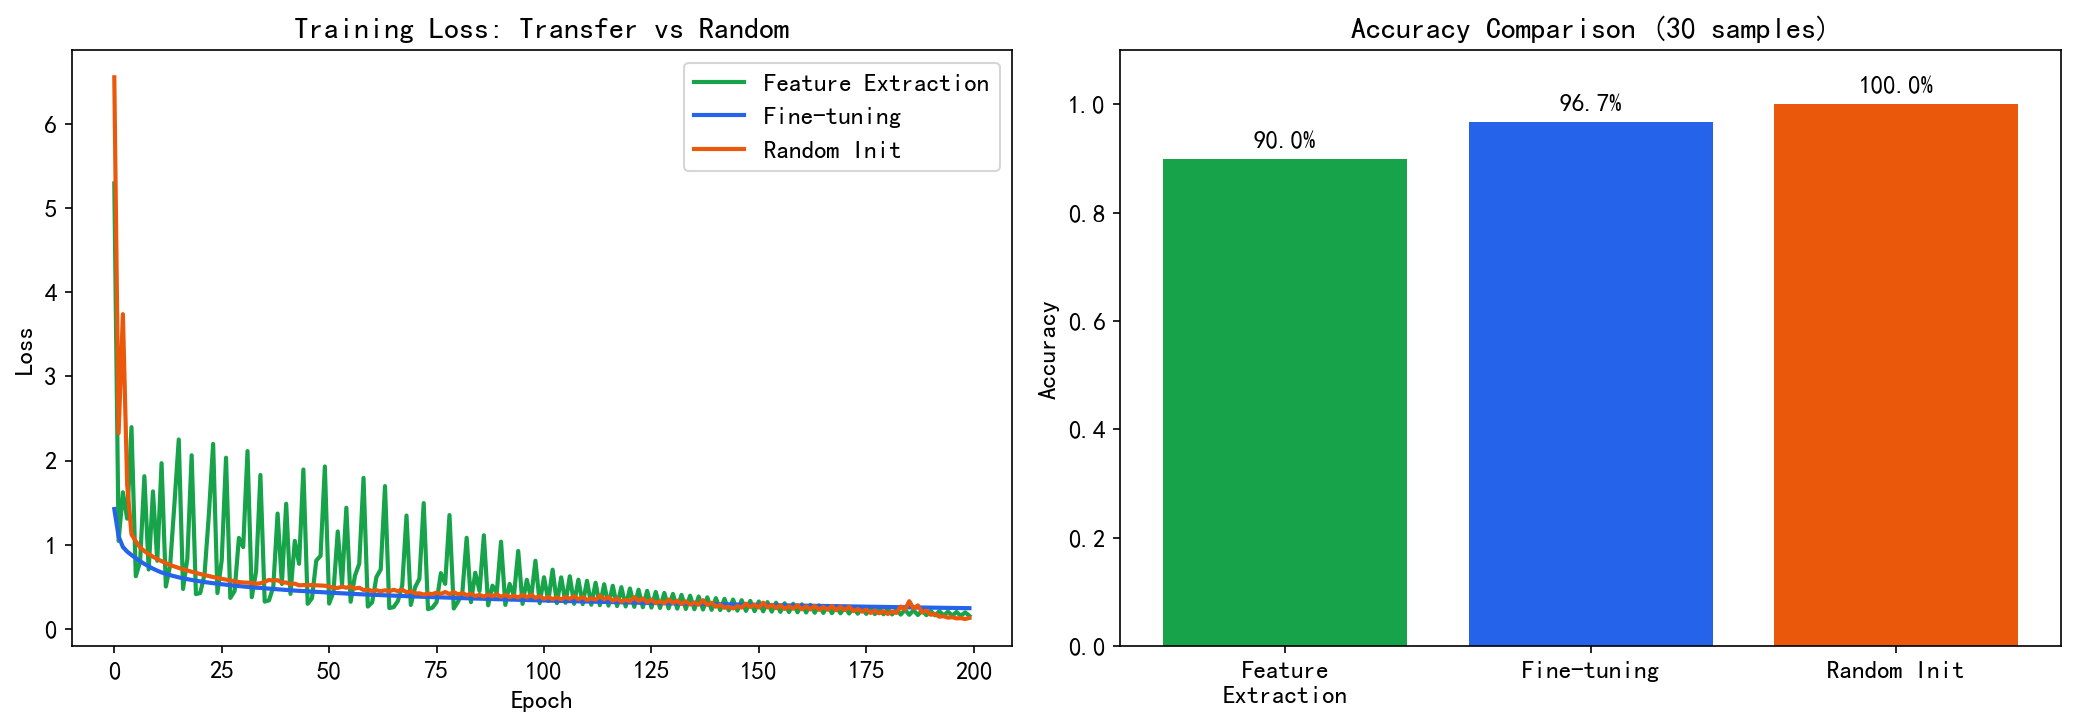

In [10]:
# Visualize transfer learning comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1 = axes[0]
ax1.plot(fe_losses, label='Feature Extraction', color='#16a34a', linewidth=2)
ax1.plot(ft_losses, label='Fine-tuning', color='#2563eb', linewidth=2)
ax1.plot(rand_losses, label='Random Init', color='#ea580c', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Transfer vs Random')
ax1.legend()

# Accuracy comparison
ax2 = axes[1]
strategies = ['Feature\nExtraction', 'Fine-tuning', 'Random Init']
accs = [fe_acc, ft_acc, rand_acc]
colors = ['#16a34a', '#2563eb', '#ea580c']
bars = ax2.bar(strategies, accs, color=colors)
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Comparison (30 samples)')
ax2.set_ylim(0, 1.1)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.1%}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('transfer_learning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Transfer learning comparison")

## 4. 渐进式解冻

### 原理

渐进式解冻（Progressive Unfreezing）逐步解冻网络层：
1. 先冻结所有预训练层，只训练分类头
2. 解冻最后一层，用小学习率训练
3. 逐步解冻更浅的层

[[Howard & Ruder, 2018]](https://arxiv.org/abs/1801.06146) ULMFiT 论文提出了这种方法。

### 学习率策略

不同层使用不同学习率（ Discriminative Learning Rates）：
- 浅层（通用特征）：小学习率（如 $10^{-5}$）
- 深层（领域特征）：中学习率（如 $10^{-4}$）
- 分类头（新参数）：大学习率（如 $10^{-3}$）

Phase 1: unfreeze layers from index 1, lr=0.1000, acc=86.67%
Phase 2: unfreeze layers from index 0, lr=0.0100, acc=96.67%
Phase 3: unfreeze layers from index 0, lr=0.0010, acc=96.67%
Visualization 3: Progressive unfreezing


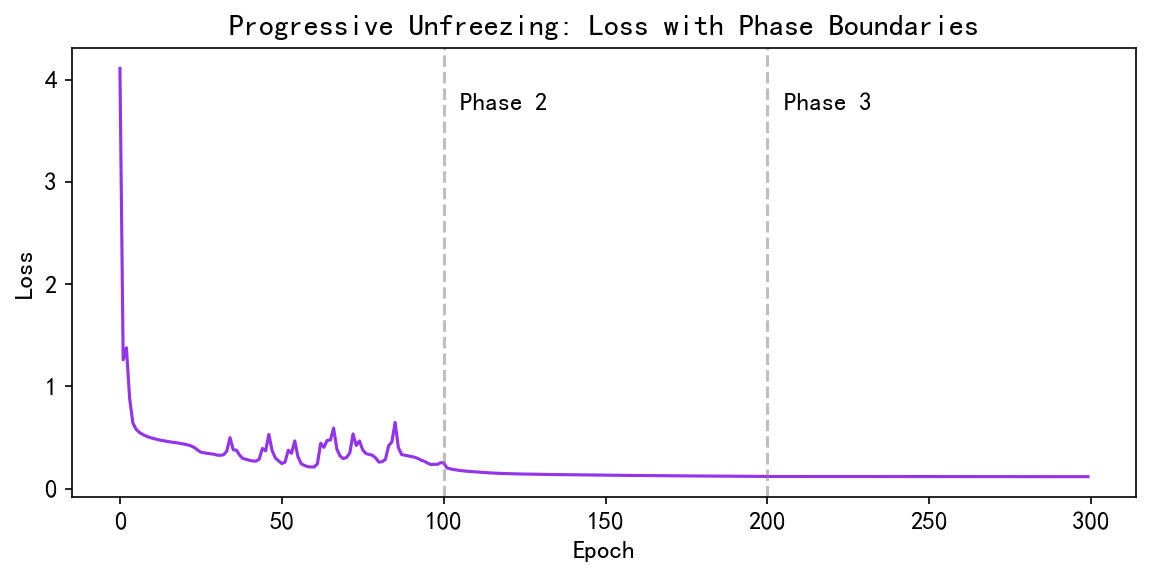

In [12]:
# Progressive unfreezing experiment
np.random.seed(42)
n_phases = 3
epochs_per_phase = 100

transfer_progressive = PretrainedModel(input_dim, [32, 16], n_target_classes)
for i in range(len(transfer_progressive.layers) - 1):
    transfer_progressive.layers[i]['W'] = pretrain_model.layers[i]['W'].copy()
    transfer_progressive.layers[i]['b'] = pretrain_model.layers[i]['b'].copy()

prog_losses = []
prog_accs = []

for phase in range(n_phases):
    freeze = (len(transfer_progressive.layers) - 1) - phase - 1
    freeze = max(freeze, 0)
    lr = 0.1 * (0.1 ** phase)  # decreasing LR
    
    for epoch in range(epochs_per_phase):
        loss = transfer_progressive.train_step(X_target, y_target, lr=lr, freeze_layers=freeze)
        prog_losses.append(loss)
    
    acc = np.mean(transfer_progressive.predict(X_target) == y_target)
    prog_accs.append(acc)
    print(f"Phase {phase+1}: unfreeze layers from index {freeze}, lr={lr:.4f}, acc={acc:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prog_losses, color='#9333ea', linewidth=1.5)
for phase in range(1, n_phases):
    ax.axvline(x=phase * epochs_per_phase, color='gray', linestyle='--', alpha=0.5)
    ax.text(phase * epochs_per_phase + 5, max(prog_losses) * 0.9, f'Phase {phase+1}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Progressive Unfreezing: Loss with Phase Boundaries')
plt.tight_layout()
plt.savefig('progressive_unfreezing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: Progressive unfreezing")

## 5. 冻结层分析

可视化预训练模型各层特征的迁移性：浅层特征更通用，深层特征更任务相关。

Layer transferability analysis:
  Layer 0 features: dim=32, linear_acc=93.33%
  Layer 1 features: dim=16, linear_acc=100.00%
Visualization 4: Layer transferability


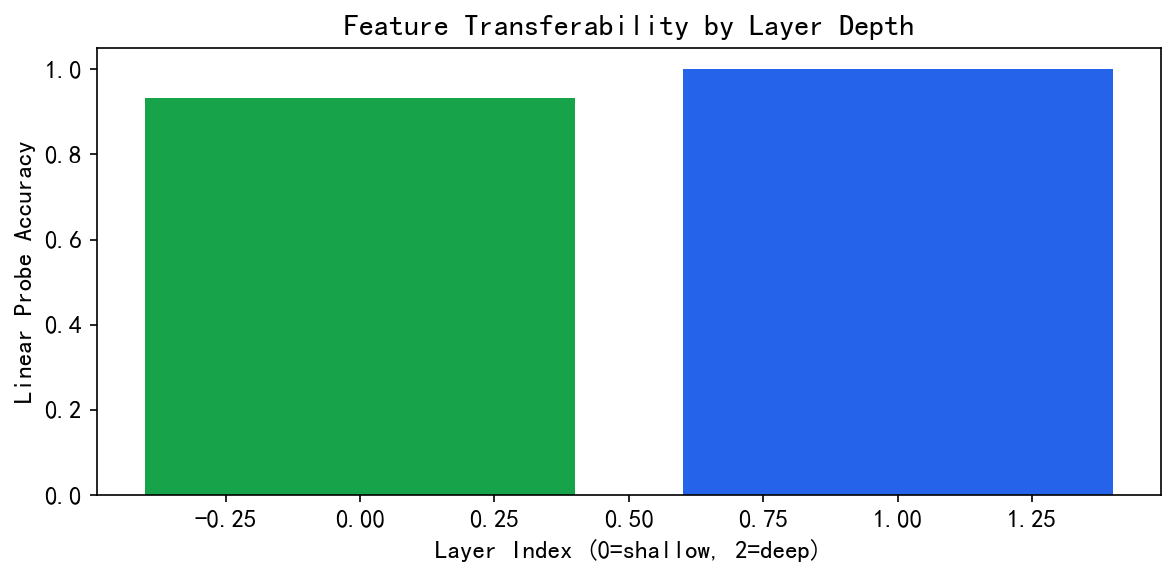

In [14]:
# Analyze feature transferability at different layers
np.random.seed(42)

# Extract features at different layers
layer_features = {}
for layer_idx in range(len(pretrain_model.layers) - 1):
    feat = pretrain_model.extract_features(X_target, layer_idx=layer_idx)
    layer_features[layer_idx] = feat

# Train linear classifier on each layer's features
def train_linear(X, y, lr=0.1, epochs=200):
    """Simple linear classifier training."""
    n_classes = len(np.unique(y))
    W = np.random.randn(n_classes, X.shape[1]) * 0.01
    b = np.zeros(n_classes)
    for _ in range(epochs):
        scores = X @ W.T + b
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_s = np.exp(shifted)
        probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
        dscores = probs.copy()
        dscores[np.arange(len(y)), y] -= 1
        dscores /= len(y)
        W -= lr * dscores.T @ X
        b -= lr * dscores.sum(axis=0)
    return np.mean(np.argmax(X @ W.T + b, axis=1) == y)

print("Layer transferability analysis:")
layer_accs = []
for layer_idx, feat in layer_features.items():
    acc = train_linear(feat, y_target, lr=0.1, epochs=300)
    layer_accs.append(acc)
    print(f"  Layer {layer_idx} features: dim={feat.shape[1]}, linear_acc={acc:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(layer_accs)), layer_accs, color=['#16a34a', '#2563eb', '#ea580c'])
ax.set_xlabel('Layer Index (0=shallow, 2=deep)')
ax.set_ylabel('Linear Probe Accuracy')
ax.set_title('Feature Transferability by Layer Depth')
plt.tight_layout()
plt.savefig('layer_transferability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: Layer transferability")

## 6. 实验观察

### 关键发现

1. **特征提取 > 随机初始化**：在 30 个小样本上，预训练特征远胜随机初始化
2. **微调通常优于特征提取**：当数据足够时，微调可以适应目标任务
3. **渐进式解冻**：稳定训练，避免灾难性遗忘
4. **浅层更可迁移**：浅层特征通用，深层特征领域相关

### 灾难性遗忘

微调时如果学习率过大，预训练知识会被快速覆盖——这就是**灾难性遗忘**。解决方案：
- 小学习率
- 渐进式解冻
- 回放策略（Replay）

## 作业

### 作业 1：实现 Discriminative Learning Rate

不同层使用不同学习率：浅层用小 LR，深层用大 LR。

In [17]:
# Homework 1: Discriminative learning rates
def train_with_discriminative_lr(model, X, y, lrs, epochs=200):
    """Train with different learning rates per layer.
    
    Args:
        lrs: list of learning rates, one per layer (shallow to deep)
    """
    # TODO: implement discriminative learning rate training
    # Key: each layer i uses lrs[i] instead of uniform lr
    pass

# Test
# model = PretrainedModel(20, [32, 16], 3)
# lrs = [0.001, 0.01, 0.1]  # shallow -> deep
# losses = train_with_discriminative_lr(model, X_target, y_target, lrs, epochs=200)
# acc = np.mean(model.predict(X_target) == y_target)
# assert acc > 0.5, "Discriminative LR should achieve >50% accuracy"
print("Homework 1 template ready. Implement discriminative learning rates.")

Homework 1 template ready. Implement discriminative learning rates.


### 作业 2：实现 Domain Adaptation

模拟域偏移（Domain Shift）：源域和目标域的分布不同。

In [19]:
# Homework 2: Domain adaptation
def domain_adaptation(source_model, X_source, y_source, X_target, y_target, 
                      n_adapt_epochs=100):
    """Adapt pretrained model to target domain.
    
    Strategy: Fine-tune with small LR on target domain.
    """
    # TODO: implement domain adaptation
    # 1. Start with source model
    # 2. Fine-tune on target with small LR
    # 3. Use early stopping to prevent overfitting
    pass

# Test
np.random.seed(42)
# Create domain-shifted data
X_target_shifted = X_target + np.random.randn(*X_target.shape) * 0.5
# acc = domain_adaptation(pretrain_model, X_pretrain, y_pretrain, 
#                          X_target_shifted, y_target)
# assert acc > 0.4, "Domain adaptation should help with distribution shift"
print("Homework 2 template ready. Implement domain adaptation.")

Homework 2 template ready. Implement domain adaptation.


### 作业 3：实现 Layer Freezing Schedule

实现一个冻结计划：训练过程中逐步解冻更多层。

In [21]:
# Homework 3: Layer freezing schedule
def freeze_schedule(model, X, y, total_epochs=300, unfreeze_every=100):
    """Gradually unfreeze layers during training.
    
    Start with all layers frozen except classifier.
    Every `unfreeze_every` epochs, unfreeze one more layer.
    """
    # TODO: implement freeze schedule
    pass

# Test
# model = PretrainedModel(20, [32, 16], 3)
# Copy pretrained weights
# losses = freeze_schedule(model, X_target, y_target, total_epochs=300, unfreeze_every=100)
# acc = np.mean(model.predict(X_target) == y_target)
# assert acc > 0.5, "Freeze schedule should achieve >50% accuracy"
print("Homework 3 template ready. Implement layer freezing schedule.")

Homework 3 template ready. Implement layer freezing schedule.


## 小结

| 策略 | 冻结层 | 训练层 | 学习率 | 适用场景 |
|------|--------|--------|--------|----------|
| **特征提取** | 所有预训练层 | 仅分类头 | 大 | 极小数据集 |
| **微调** | 无 | 全部 | 统一 | 中等数据集 |
| **渐进式解冻** | 逐层减少 | 从深到浅 | 递减 | 平衡稳定与性能 |
| **判别式 LR** | 无 | 全部 | 逐层递增 | 精细微调 |

**关键洞察**：迁移学习是深度学习最实用的技术——大多数实际应用不需要从头训练。预训练模型的浅层特征具有通用性，迁移到新任务只需少量数据即可获得良好效果。

## 参考文献

1. [[Yosinski et al., 2014]](https://arxiv.org/abs/1411.1792) Yosinski et al. *How transferable are features in deep neural networks?* NIPS 2014.
2. [[Howard & Ruder, 2018]](https://arxiv.org/abs/1801.06146) Howard & Ruder. *Universal Language Model Fine-tuning for Text Classification*. ACL 2018.
3. [[Donahue et al., 2014]](https://arxiv.org/abs/1310.1531) Donahue et al. *DeCAF: A Deep Convolutional Activation Feature for Generic Visual Recognition*. ICML 2014.
4. [[Razavian et al., 2014]](https://arxiv.org/abs/1403.6382) Razavian et al. *CNN Features off-the-shelf*. CVPR Workshop 2014.
5. [[Kirkpatrick et al., 2017]](https://arxiv.org/abs/1612.00796) Kirkpatrick et al. *Overcoming Catastrophic Forgetting in Neural Networks*. PNAS 2017.

---

> 本节内容参考 [Stanford CS231n](https://cs231n.stanford.edu/) | [Transfer Learning](https://cs231n.github.io/transfer-learning/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[huggingface/pytorch-image-models](https://github.com/huggingface/pytorch-image-models)** (37139 stars): PyTorch 图像模型库（含大量预训练模型和迁移学习工具）
  - 仓库地址: https://github.com/huggingface/pytorch-image-models

- **[seloufian/Deep-Learning-Computer-Vision](https://github.com/seloufian/Deep-Learning-Computer-Vision)** (135 stars): 深度学习计算机视觉实践（含迁移学习教程）
  - 仓库地址: https://github.com/seloufian/Deep-Learning-Computer-Vision

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.